In [1]:
"""
Authors: Dylan Jacobs, Jonah Pflaster, Pablo Velarde
Date: 30 April, 2026
"""


# %% 1- Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import random
from torch.utils.data import random_split, Dataset
from google.colab import drive
import gc
import shutil
import os
import zipfile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Mount drive to access dataset from Colab
drive.mount('/content/drive')

shutil.copy("/content/drive/MyDrive/Colab Notebooks/png_ready.zip", "/content/png_ready.zip")

# Unzip locally
with zipfile.ZipFile("/content/png_ready.zip", 'r') as z:
    z.extractall("/content/data")


Using device: cuda
Mounted at /content/drive


In [8]:
batch_size = 150
img_size = 128

root = "/content/drive/MyDrive/Colab Notebooks/png_ready"
root = "/content/data/png_ready"

# root = "./data"
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.12, 0.12), scale=(0.8, 1.2)),
    transforms.RandomRotation(degrees=15),
    #transforms.RandomPerspective(distortion_scale=0.4, p=0.4),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

dataset = torchvision.datasets.ImageFolder(root=root, transform=None)

# split into train, validation, test
train_test_split = 0.9
train_val_split = 0.8
full_dataset_len = len(dataset)
full_train_len = int(train_test_split * len(dataset))
test_len = full_dataset_len - full_train_len
[full_trainset, testset] = random_split(dataset, [full_train_len, test_len])

# split train into train/val
train_len = int(train_val_split * full_train_len)
val_len = full_train_len - train_len
[trainset, valset] = random_split(full_trainset, [train_len, val_len])

class TransformDataset(Dataset):
  def __init__(self, dataset, transform):
    self.dataset = dataset
    self.transform = transform

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    image, label = self.dataset[idx]
    if self.transform:
      image = self.transform(image)
    return image, label

# apply different transforms
#trainset.dataset.transform = train_transform
#valset.dataset.transform = eval_transform
#testset.dataset.transform = eval_transform
trainset = TransformDataset(trainset, train_transform)
valset = TransformDataset(valset, eval_transform)
testset = TransformDataset(testset, eval_transform)

print(f'Training length: ', train_len)
print(f'Validation length: ', val_len)
print(f'Testing length: ', test_len)

# Create torch dataloaders
train_loader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    num_workers=2,
    pin_memory=True,      # faster CPU->GPU transfer
    prefetch_factor=2,    # prefetch batches ahead of time
    persistent_workers=True,  # don't restart workers each epoch
    shuffle=True)
val_loader = torch.utils.data.DataLoader(
    valset,
    batch_size=batch_size,
    num_workers=2,
    pin_memory=True,      # faster CPU->GPU transfer
    prefetch_factor=2,    # prefetch batches ahead of time
    persistent_workers=True,  # don't restart workers each epochs
    shuffle=False)
test_loader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    num_workers=2,
    pin_memory=True,      # faster CPU->GPU transfer
    prefetch_factor=2,    # prefetch batches ahead of time
    persistent_workers=True,  # don't restart workers each epoch
    shuffle=False)


Training length:  14400
Validation length:  3600
Testing length:  2000


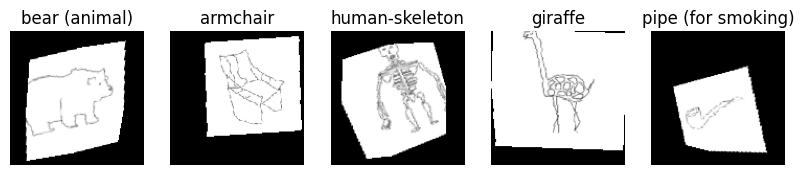

In [3]:

# %% Preview images
def preview_images(data_loader, classes):
    data_iter = iter(data_loader)
    images, labels = next(data_iter)

    fig, axes = plt.subplots(1, 5, figsize=(10, 5))
    for i, ax in enumerate(axes):
        rand = random.randint(0, len(images) - 1)
        img = images[i + rand]
        img = img.permute(1, 2, 0).numpy() # reshape into correct size for image
        ax.imshow(img, cmap='gray')
        ax.set_title(classes[labels[i + rand].item()])
        ax.axis('off')
    plt.show()

classes = dataset.classes
preview_images(train_loader, classes)



In [9]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)

        self.batch_norm1 = nn.BatchNorm2d(32)
        self.batch_norm2 = nn.BatchNorm2d(64)
        self.batch_norm3 = nn.BatchNorm2d(128)
        self.batch_norm4 = nn.BatchNorm2d(256)
        self.batch_norm5 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(512 * 4 * 4, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc_out = nn.Linear(256, 250)

    def forward(self, x):
        x = self.pool(torch.relu(self.batch_norm1(self.conv1(x))))
        x = self.pool(torch.relu(self.batch_norm2(self.conv2(x))))
        x = self.pool(torch.relu(self.batch_norm3(self.conv3(x))))
        x = self.pool(torch.relu(self.batch_norm4(self.conv4(x))))
        x = self.pool(torch.relu(self.batch_norm5(self.conv5(x))))

        x = torch.flatten(x, 1) # need to flatten for fully connected layers
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)

        x = torch.relu(self.fc2(x))
        x = self.dropout(x)

        x = torch.relu(self.fc3(x))
        x = self.dropout(x)

        x = self.fc_out(x) # no need for relu bc torch does softmax automatically
        return x


In [10]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1)

def save_checkpoint(model, optimizer, epoch, loss):
  torch.save({
      'epoch': epoch,
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict(),
      'loss': loss
  }, '/content/drive/My Drive/Colab Notebooks/checkpoint.pth')

def train_model(model, train_loader, val_loader, epochs=10):
    train_losses, val_losses = [], [] # track for loss curves
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        total_val_loss   = 0.0
        train_total_correct    = 0.0
        train_total_images     = 0.0
        val_total_correct      = 0.0
        val_total_images       = 0.0

        # training step
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            output = model(images)

            predictions = torch.max(output, 1)[1]

            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            train_total_correct += (predictions == labels).sum().item()
            train_total_images += labels.size(0)

        train_accuracy = 100 * train_total_correct / train_total_images

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)

        # validation step
        model.eval()
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                output = model(images)

                predictions = torch.max(output, 1)[1]

                loss = criterion(output, labels)

                total_val_loss += loss.item()

                val_total_correct += (predictions == labels).sum().item()
                val_total_images += labels.size(0)

        val_accuracy = 100 * val_total_correct / val_total_images

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)

        # update LR if necessary according to validation
        lr_scheduler.step(avg_val_loss)

        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4}, Val Loss: {avg_val_loss:.4}, Learning Rate: {optimizer.param_groups[0]['lr']:.6}, Training Accuracy: {train_accuracy:.4}%, Validation Accuracy: {val_accuracy:.4}%')
        if avg_val_loss == min(val_losses):
          save_checkpoint(model, optimizer, epoch, avg_val_loss)
    return train_losses, val_losses, train_accuracies, val_accuracies


train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, train_loader, val_loader, epochs=100)
print('Finished training')

Epoch 1/100, Train Loss: 5.553, Val Loss: 5.523, Learning Rate: 0.001, Training Accuracy: 0.3125%, Validation Accuracy: 0.25%
Epoch 2/100, Train Loss: 5.524, Val Loss: 5.524, Learning Rate: 0.001, Training Accuracy: 0.4306%, Validation Accuracy: 0.2778%
Epoch 3/100, Train Loss: 5.523, Val Loss: 5.524, Learning Rate: 0.001, Training Accuracy: 0.4167%, Validation Accuracy: 0.2778%
Epoch 4/100, Train Loss: 5.522, Val Loss: 5.524, Learning Rate: 0.001, Training Accuracy: 0.4167%, Validation Accuracy: 0.2778%
Epoch 5/100, Train Loss: 5.506, Val Loss: 5.423, Learning Rate: 0.001, Training Accuracy: 0.5278%, Validation Accuracy: 0.5833%
Epoch 6/100, Train Loss: 5.403, Val Loss: 5.33, Learning Rate: 0.001, Training Accuracy: 0.7361%, Validation Accuracy: 0.8611%
Epoch 7/100, Train Loss: 5.338, Val Loss: 5.376, Learning Rate: 0.001, Training Accuracy: 0.8611%, Validation Accuracy: 0.6389%
Epoch 8/100, Train Loss: 5.312, Val Loss: 5.973, Learning Rate: 0.001, Training Accuracy: 0.8542%, Validati

In [11]:
# %% Evaluate on test set
def evaluate_model(model, loader):

  correct = 0
  total = 0
  model.eval()

  with torch.no_grad():
    for images, labels in loader:
      images, labels = images.to(device), labels.to(device)
      output = model(images)

      _, predictions = torch.max(output.data, 1)
      total += labels.size(0)
      correct += (predictions == labels).sum().item()

  accuracy = 100 * correct / total
  print(f'Accuracy on test set: {accuracy:.2f}%')
  return accuracy

test_accuracy = evaluate_model(model, test_loader)

Accuracy on test set: 59.75%


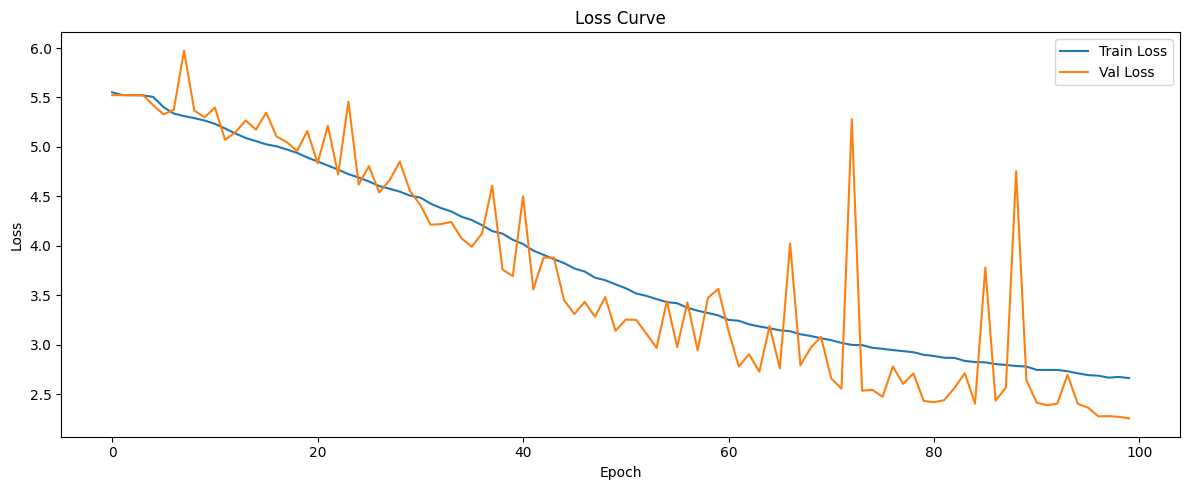

In [12]:
# %% 13 - Plot Loss and Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Loss")
plt.plot(val_accuracies, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

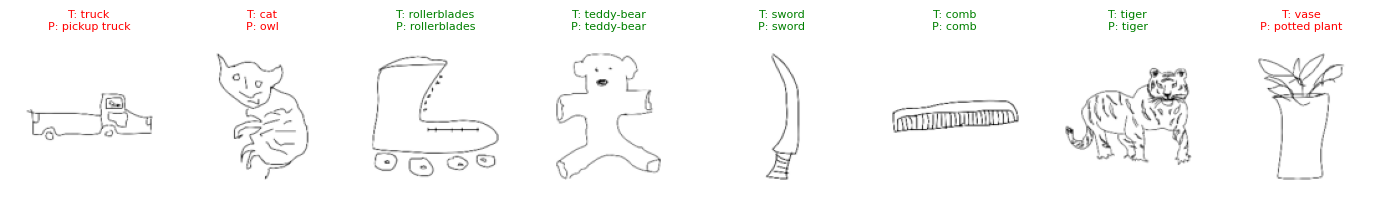

In [13]:
# %% 15 - Show Predictions
def show_predictions(model, loader, class_names, num_samples=8):
    model.eval()
    images, labels = next(iter(loader))

    plt.figure(figsize=(14, 4))
    starting_point = random.randint(0, len(images) - num_samples)
    for i in range(starting_point, starting_point + num_samples):
        image = images[i].unsqueeze(0).to(device)
        true_label = labels[i].item()

        with torch.no_grad():
            output = model(image)
            pred_label = torch.argmax(output, dim=1).item()

        plt.subplot(1, num_samples, i - starting_point + 1)
        plt.imshow(images[i].squeeze().numpy(), cmap='gray')
        plt.title(
            f"T: {class_names[true_label]}\nP: {class_names[pred_label]}",
            color="green" if true_label == pred_label else "red",
            fontsize=8
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, val_loader, dataset.classes)

In [14]:
# %% 16 - Save Model
save_path = "/content/drive/MyDrive/Colab Notebooks/cnn_image_classification_model2.pth"
torch.save(model.state_dict(), save_path)
print("Model saved to:", save_path)

Model saved to: /content/drive/MyDrive/Colab Notebooks/cnn_image_classification_model2.pth


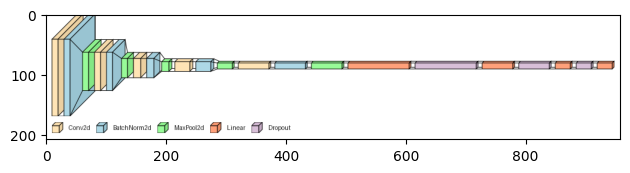

In [28]:
def visualize_model(model):
    import torch.onnx
    import copy
    import visualtorch
    dummy_input = torch.randn(1, 1, 128, 128).to(device)
    model_cpu = copy.deepcopy(model).cpu()
    #torch.onnx.export(model, dummy_input, "cnn_image_classification_model.onnx")
    img = visualtorch.layered_view(model_cpu, input_shape=(1, 1, 128, 128), legend=True)
    img.save("architecture.png")
    plt.imshow(img)
    plt.tight_layout()
    plt.show()
visualize_model(model)

